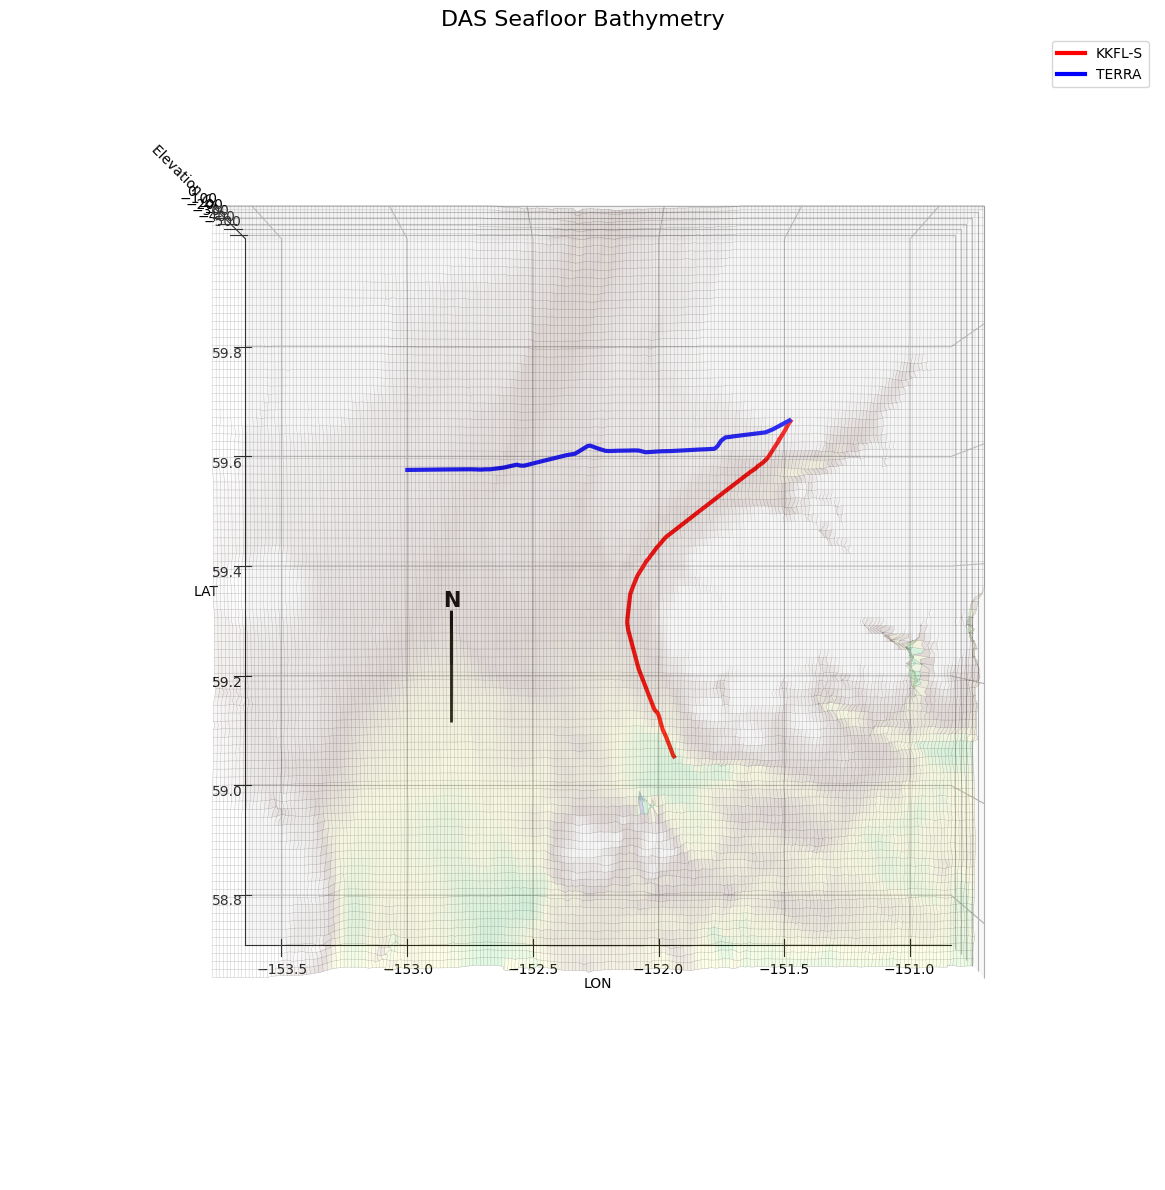

In [1]:
# bathymetry map

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def bathymetry_cable_plot():
    try:
        kkfls = pd.read_csv('../das_coords_bathymetry/KKFLS_coords.xycz', sep=r'\s+', header=None, names=['lon','lat','cha','dep'])
        terra = pd.read_csv('../das_coords_bathymetry/TERRA_coords.xycz', sep=r'\s+', header=None, names=['lon','lat','cha','dep'])
        bathymetry = pd.read_csv('../das_coords_bathymetry/PW24.xyz', sep=r'\s+', header=None, names=['lon','lat','elevation'])    
    except FileNotFoundError as e:
        print(f"Error: Could not find file. {e}")
        return

    kkfls = kkfls.dropna()
    terra = terra.dropna()
    bathymetry['lon_adj'] = bathymetry['lon'].apply(lambda x: x - 360 if x > 180 else x)

    # 10km map buffer
    km_per_deg_lat = 111.13 / 4
    km_per_deg_lon = 111.32 * np.cos(np.radians(59.5)) / 4
    
    buffer_km = 10
    buffer_lat_deg = buffer_km / km_per_deg_lat
    buffer_lon_deg = buffer_km / km_per_deg_lon

    min_lon_cable = min(kkfls['lon'].min(), terra['lon'].min())
    max_lon_cable = max(kkfls['lon'].max(), terra['lon'].max())
    min_lat_cable = min(kkfls['lat'].min(), terra['lat'].min())
    max_lat_cable = max(kkfls['lat'].max(), terra['lat'].max())

    min_lon = min_lon_cable - buffer_lon_deg
    max_lon = max_lon_cable + buffer_lon_deg
    min_lat = min_lat_cable - buffer_lat_deg
    max_lat = max_lat_cable + buffer_lat_deg
    
    
    bathy_subset = bathymetry[
        (bathymetry['lon_adj'] >= min_lon) & (bathymetry['lon_adj'] <= max_lon) &
        (bathymetry['lat'] >= min_lat) & (bathymetry['lat'] <= max_lat)
    ]

    if bathy_subset.empty:
        print("Error: No bathymetry data found in this region. Check coordinate systems.")
        return

    bathy_pivot = bathy_subset.pivot(index='lat', columns='lon_adj', values='elevation')
    X_vals = bathy_pivot.columns.values
    Y_vals = bathy_pivot.index.values
    X, Y = np.meshgrid(X_vals, Y_vals)
    Z = bathy_pivot.values
    
    # setting all land to zero depth
    Z[Z > 0] = 0
    Z_min = np.nanmin(Z)
    Z_max = np.nanmax(Z) 
    
    fig = plt.figure(figsize=(14, 12))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlim(X_vals.min(), X_vals.max())
    ax.set_ylim(Y_vals.min(), Y_vals.max())
    ax.set_zlim(Z_min, Z_max) 

    ax.plot_wireframe(X, Y, Z, color='black', alpha=0.3, linewidth=0.3, rstride=2, cstride=2)
    ax.plot_surface(X, Y, Z, cmap='terrain', alpha=0.2, rstride=2, cstride=2, shade=False)
    ax.plot(kkfls['lon'], kkfls['lat'], kkfls['dep'], color='red', linewidth=3, label='KKFL-S')
    ax.plot(terra['lon'], terra['lat'], terra['dep'], color='blue', linewidth=3, label='TERRA')

    # Adjust to change view
    ax.view_init(elev=90, azim=-90)
    
    # Arrow positioning stuff, neither integral nor precise
    arrow_x = min_lon_cable + (max_lon_cable - min_lon_cable) * 0.1
    arrow_y = min_lat_cable + (max_lat_cable - min_lat_cable) * 0.1
    ix = (np.abs(bathy_pivot.columns - arrow_x)).argmin()
    iy = (np.abs(bathy_pivot.index - arrow_y)).argmin()
    z_floor = bathy_pivot.iloc[iy, ix]
    
    # Places arrow down the Z-axis, 0.75 = 75% of the way down
    arrow_z = Z_min + (Z_max - Z_min) * 0.5
    arrow_len = (max_lat - min_lat) * 0.15
    ax.quiver(arrow_x, arrow_y, arrow_z, 0, arrow_len, 0, 
              color='black', linewidth=2, arrow_length_ratio=0.5)
    
    ax.text(arrow_x, arrow_y + arrow_len, arrow_z, "N", 
            color='black', fontsize=15, fontweight='bold', ha='center', va='bottom')

    ax.set_title('DAS Seafloor Bathymetry', fontsize=16)
    ax.set_xlabel('LON')
    ax.set_ylabel('LAT')
    ax.set_zlabel('Elevation (m)')
    ax.legend()

    output_file = 'das_seafloor_bathymetry.png'
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()



bathymetry_cable_plot()